# Main Fig 5 — Min-cost frontier

**Layout**: 2 rows × 3 cols (mosaic), lower row centred  
Legend appears once, outside panel (e) on the right.  
Increase ROW_H for larger panels.

In [26]:
%matplotlib inline

In [27]:
import sys
from pathlib import Path

# ── Workspace root: auto-detect by looking for final_results/ ─────────────────
def _find_workspace():
    """Walk up from CWD until we find a directory containing final_results/."""
    candidate = Path.cwd().resolve()
    for _ in range(10):
        if (candidate / "final_results").exists():
            return candidate
        if candidate.parent == candidate:
            break
        candidate = candidate.parent
    # Explicit fallback (edit this if auto-detect fails)
    return Path("/Users/boshra/NSRR-workspace").resolve()

WORKSPACE_ROOT = _find_workspace()
NSRR_TOOLS     = WORKSPACE_ROOT / "NSRR-tools"
FINAL_RESULTS  = WORKSPACE_ROOT / "final_results"
PAPER_FIGURES  = NSRR_TOOLS / "results" / "paper_figures"
FINAL_OUT      = PAPER_FIGURES / "final"
FINAL_OUT.mkdir(parents=True, exist_ok=True)

# Add utils to path (notebooks/utils/)
_nb_dir = PAPER_FIGURES / "notebooks"
sys.path.insert(0, str(_nb_dir))

from utils.style import (
    apply_tbme_style, save_figure, FULL_W, HALF_W,
    MAIN_TASKS, SUPP_TASKS, ALL_TASKS, BINARY_MAIN,
    HEAD_STYLE, TASK_LABEL, FONT_ANNOT, FONT_BASE, FONT_LABEL,
)
from utils.data import set_root, load_analysis, load_heatmap, load_parquets
from utils import panels

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

set_root(WORKSPACE_ROOT)
apply_tbme_style()

# ── Confirm the workspace root is correct ─────────────────────────────────────
_ok = (WORKSPACE_ROOT / "final_results").exists()
print(f"WORKSPACE_ROOT : {WORKSPACE_ROOT}")
print(f"final_results/ : {'✓ found' if _ok else '✗ NOT FOUND — edit _find_workspace() fallback'}")

WORKSPACE_ROOT : /Users/boshra/NSRR-workspace
final_results/ : ✓ found


In [28]:
# Panel labeling helper
def add_panel_label(ax, label, x=0.02, y=0.97):
    ax.text(x, y, label, transform=ax.transAxes,
            fontsize=8, fontweight="bold", va="top", fontfamily="serif")

In [29]:
HEAD   = "transformer"
TASKS  = MAIN_TASKS
METRIC = "auroc"
N_COLS = 3
N_ROWS = (len(TASKS) + N_COLS - 1) // N_COLS
ROW_H  = 2.0   # inches per row

hmaps = {t: load_heatmap("phase0_v3", t, HEAD) for t in TASKS}

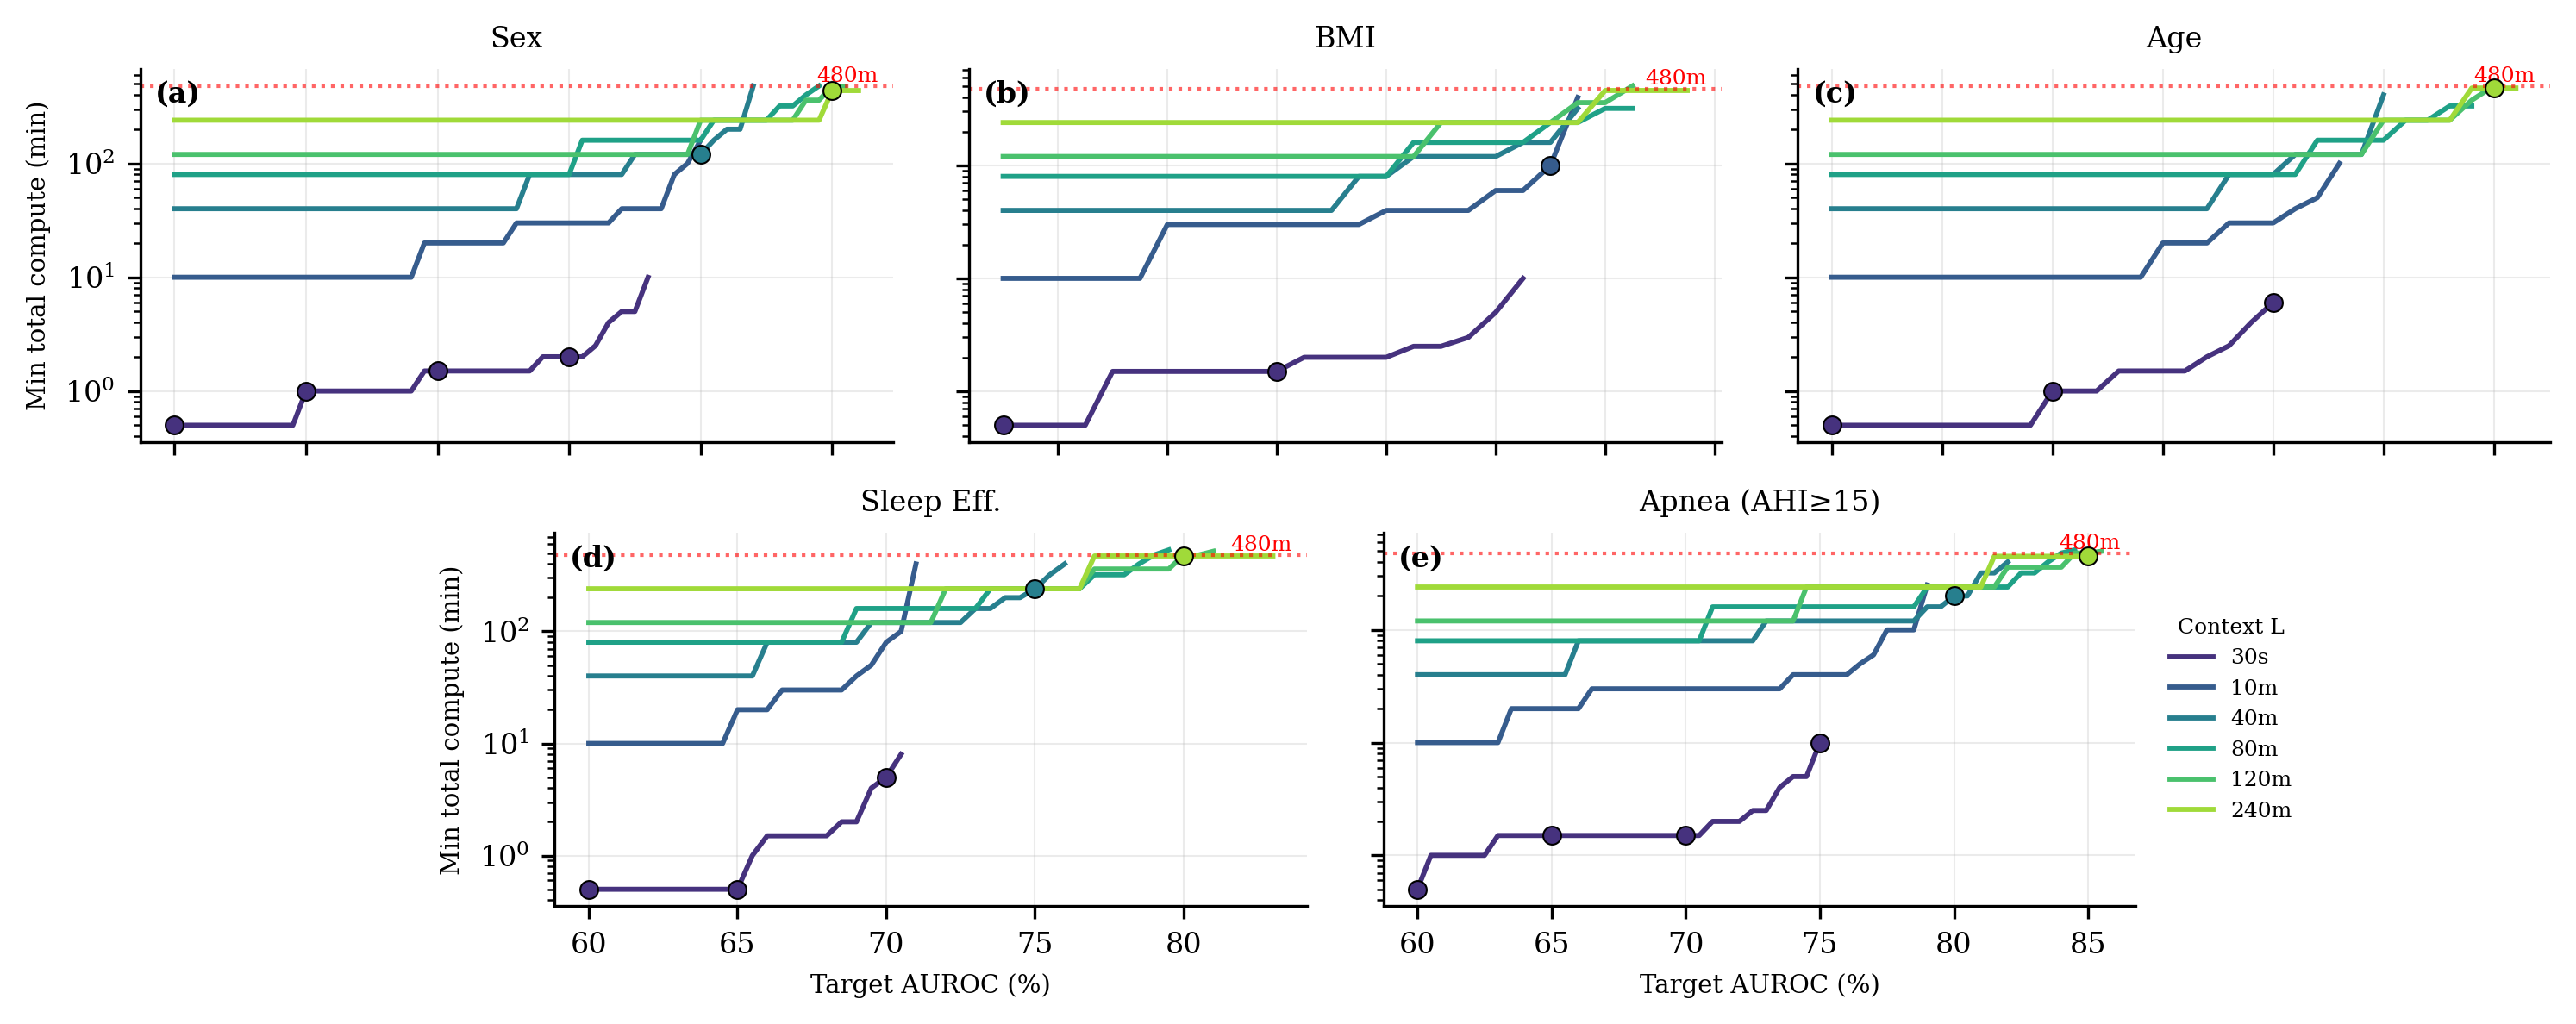

In [35]:
# ── Mosaic: last row centred ──────────────────────────────────────────────────
labels = [chr(97 + i) for i in range(len(TASKS))]
n_last = len(TASKS) % N_COLS or N_COLS
n_full = len(TASKS) // N_COLS

mosaic = []
for row in range(n_full):
    row_labels = labels[row * N_COLS : (row + 1) * N_COLS]
    mosaic.append([lbl for lbl in row_labels for _ in range(2)])
if n_last < N_COLS:
    pad = N_COLS - n_last
    last_labels = labels[n_full * N_COLS:]
    mosaic.append(["."] * pad +
                  [lbl for lbl in last_labels for _ in range(2)] +
                  ["."] * pad)

fig, axd = plt.subplot_mosaic(mosaic, figsize=(FULL_W+3, N_ROWS * ROW_H))

# ── Draw panels ───────────────────────────────────────────────────────────────
for i, (lbl, task) in enumerate(zip(labels, TASKS)):
    panels.mincost_panel(axd[lbl], hmaps[task], col=METRIC)
    axd[lbl].set_title(TASK_LABEL[task], fontsize=8)
    add_panel_label(axd[lbl], f"({chr(97 + i)})")

# ── Collect legend handles BEFORE removing legends ────────────────────────────
handles, leg_labels = axd[labels[0]].get_legend_handles_labels()
for lbl in labels:
    if axd[lbl].get_legend():
        axd[lbl].get_legend().remove()

# ── Strip x-labels from top row (shared by bottom row) ───────────────────────
for lbl in labels[:N_COLS]:
    axd[lbl].set_xlabel("")
    axd[lbl].tick_params(labelbottom=False)

# ── Strip y-labels from non-leftmost panels of each row ──────────────────────
for i, lbl in enumerate(labels):
    if i % N_COLS != 0:
        axd[lbl].set_ylabel("")
        axd[lbl].tick_params(labelleft=False)

# ── Single legend outside bottom-right panel (e) ─────────────────────────────
axd[labels[-1]].legend(
    handles, leg_labels,
    title="Context L", title_fontsize=FONT_ANNOT,
    fontsize=FONT_ANNOT, frameon=False,
    loc="center left", bbox_to_anchor=(1.02, 0.5),
)

fig.tight_layout(h_pad=1.2, w_pad=-3)
plt.show()

In [36]:
# ── Run when figure looks good ──────────────────────────────────
save_figure(fig, FINAL_OUT, "main_fig5_mincost")
print("Saved →", FINAL_OUT / "main_fig5_mincost.pdf")

  saved → /Users/boshra/NSRR-workspace/NSRR-tools/results/paper_figures/final/main_fig5_mincost.pdf
Saved → /Users/boshra/NSRR-workspace/NSRR-tools/results/paper_figures/final/main_fig5_mincost.pdf
